# D209 Task 1 Performance Assessment

## Part 1: Research Question

### A. Describe the purpose of this data mining report by doing the following:

#### 1. Propose one question relevant to a real-world organizational situation that you will answer using one of the following classification methods: k-nearest neighbor (KNN), Naive Bayes

One question relevant to a real-world organizational situation that I will answer using the k-nearest neighbor classification method is, "Can it be accuractely predicted whether a patient will be readmitted within one month of release based on certain factors?"

#### 2. Define one goal of the data analysis. Ensure that your goal is reasonable within the scope of the scenario and is represented in the available data.

The primary goal of the data analysis is to use a k-nearest neighbors machine learning model to predict whether a patient will be readmitted within one month of release based on certain factors. As the scenario pertains to understanding patient readmission better, being able to accurately classify whether a patient will be readmitted within one month would likely benefit the organization. The categorical 'ReAdmis' variable can be used as the target variable.

## Part II: Method Justification

### B. Explain the reasons for your chosen classification method from part A1 by doing the following:

#### 1. Explain how the classification method you chose analyzes the selected data set. Include expected outcomes.

According to IBM, "The k-nearest neighbors algorithm, also known as KNN or k-NN, is a non-parametric, supervised learning classifier, which uses proximity to make classifications or predictions about the grouping of an individual data point. While it can be used for either regression or classification problems, it is typically used as a classification algorithm, working off the assumption that similar points can be found near one another."

Additionally, Slide 17 of D209 Data Mining Task 1 Cohort notes, "The basic idea of k_nn is to predict the label of any data point by looking at the 'k' closest labeled data point, for example, 5 closest labeled data points, and getting them to vote on what the unlabeled point should have. The new data point is then assigned the label of the majority of the 'k' closest points. k-NN uses distance, and the standard Euclidean distance is the most common and default choice."

In short, the KNN classifier attempts to predict the labels of unlabeled variables by using a determined number of nearby points to aid in achieving an accurate prediction. Identifying the optimal number of nearby points, 'k', as well as ensuring that the data is properly prepared are both essential when it comes to correctly implementing the KNN classification method. For the selected medical data set, the KNN classifier method will attempt to predict which factors are most impacting the patients' likelihood to be readmitted within one month of release.

#### 2. Summarize one assumption of the chosen classification method.

Unite.ai notes that "the primary assumption that a KNN model makes is that data points/instances which exist in close proximity to each other are highly similar, while if a data point is far away from another group it's dissimilar to those data points." 

This assumption makes sense when considering how the KNN classifier works. The classifier labels unlabeled points based on the labels nearby the unlabeled point. If this assumption does not hold, then the entire method of the classifier is irrelevant. If nearby values were not deemed as more similar for unlabeled points than faraway values, then the classifier would essentially operate at random, which would not be ideal for a classifier.

#### 3. List the packages or libraries you have chosen for Python or R, and justify how each item on the list supports the analysis.

The following packages or libraries were used to support the analysis:

Pandas: Used to read the initial CSV file into Python, as well as any time a DataFrame operation was needed.

Scipy.stats: Used to generate Z-scores for outlier assessment during exploratory data analysis

Matplotlib.pyplot: Used to plot histograms during exploratory data analysis, as well as showing graphs for the correlation matrix and ROC curve

Seaborn: Used to generate boxplots for exploratory data analysis, as well as the heatmap for the correlation matrix.

MinMaxScaler: Used for feature scaling, MinMaxScaler was used because binary variables are 0 or 1 and MinMaxScaler scales all variables from 0 to 1.

SelectKBest: Used for feature selection in order to identify the optimal features to keep.

F_classif: Used to assist the SelectKBest operator. Specifies that the f-statistic will be used, which allows us to select the best features based on p-value.

Variance_inflation_factor: Used to assess whether there is multicollinearity among the selected variables.

Train_test_split: Used to split the data into training and test sets in order for the KNN classifier to properly operate.

Numpy: Used to set up the parameters for the KNN Classifier.

KNeighborsClassifier: Used to instantiate the KNN model as well as specify the best parameter for k.

GridSearchCV: Used to cross-validate the KNN classifier in order to assist in specifying the best parameter for k.

Confusion_matrix: Used to generate the confusion matrix for the KNN classifier, allowing for the assessment of model performance.

Roc_auc_score: Used to generate the AUC score for the KNN model, which allows for further assessment of model performance.

Roc_curve: Allows the ROC curve to be plotted, helps to create a visualization to assist in model performance assessment.

Classification_report: Creates a report of model performance, which, in combination with other model performance aspects, allows us a robust determination of how well the model performs.

## Part III: Data Preparation

### C. Perform data preparation for the chosen data set by doing the following:

#### 1. Describe one data preprocessing goal relevant to the classification method from part A1.

There are a variety of data preprocessing goals relevant to the KNN classification method. One of particular importance is feature scaling, which is vital to ensuring that the k-NN classifier operates correctly. MinMaxScaler() was used instead of StandardScaler() because MinMaxScaler typically scales features to have a range between 0 and 1. As a mix of continuous variables and binary categorical variables (whose response are either 0 or 1) were used as variables, it seems prudent to also scale the continuous variables to between 0 and 1 as well. 

Scaling is important to the KNN classifier because without scaling, features with larger ranges could "dominate" the distance calculation that is essential to the functioning of the classifier. For example, if the number of children ranges from 0 to 8, while income ranges from 0 to 150,000, income will dominate the distance calculation and could potentially lead to the "children" feature becoming less useful. By scaling both values to be between 0 and 1, we can ensure that both features are treated more similarly, leading to a hopefully more accurate classifier.

#### 2. Identify the initial data set variables that you will use to perform the analysis for the classification question from part A1, and classify each variable as numeric or categorical.

The below variables were the initial data set variables used to perform the KNN classification analysis. The variables not kept were ignored due to either being a patient ID, demographic data that seemed difficult to work with for the level of insight it could potentially offer (Zip, Population, Job), or survey response data (which seemed difficult to incorporate in a way that would yield interpretable results).


| Variable | Category |
| --- | --- |
| Children | Numeric |
| Age | Numeric |
| Income | Numeric |
| VitD_levels | Numeric |
| Doc_visits | Numeric |
| Full_meals_eaten | Numeric |
| vitD_supp | Numeric |
| Initial_days | Numeric |
| TotalCharge | Numeric |
| Additional_charges | Numeric |
| Area | Categorical |
| Marital | Categorical |
| Gender | Categorical |
| ReAdmis | Categorical |
| Soft_drink | Categorical |
| Initial_admin | Categorical |
| HighBlood | Categorical |
| Stroke | Categorical |
| Complication_risk | Categorical |
| Overweight | Categorical |
| Arthritis | Categorical |
| Diabetes | Categorical |
| Hyperlipidemia | Categorical |
| BackPain | Categorical |
| Anxiety | Categorical |
| Allergic_rhinitis | Categorical |
| Reflux_esophagitis | Categorical |
| Asthma | Categorical |
| Services | Categorical |

#### 3. Explain each of the steps used to prepare the data for the analysis. Identify the code segment for each step.

<b>Read in the file and take a quick look at the data:</b>

In [1]:
#Import libraries
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report

#Question C3 - Data preprocessing for k-NN model
#Read in file
file = "medical_clean.csv"
medical_data = pd.read_csv(file)

#View the data
print(medical_data.head())

   CaseOrder Customer_id                           Interaction   
0          1     C412403  8cd49b13-f45a-4b47-a2bd-173ffa932c2f  \
1          2     Z919181  d2450b70-0337-4406-bdbb-bc1037f1734c   
2          3     F995323  a2057123-abf5-4a2c-abad-8ffe33512562   
3          4     A879973  1dec528d-eb34-4079-adce-0d7a40e82205   
4          5     C544523  5885f56b-d6da-43a3-8760-83583af94266   

                                UID          City State        County    Zip   
0  3a83ddb66e2ae73798bdf1d705dc0932           Eva    AL        Morgan  35621  \
1  176354c5eef714957d486009feabf195      Marianna    FL       Jackson  32446   
2  e19a0fa00aeda885b8a436757e889bc9   Sioux Falls    SD     Minnehaha  57110   
3  cd17d7b6d152cb6f23957346d11c3f07  New Richland    MN        Waseca  56072   
4  d2f0425877b10ed6bb381f3e2579424a    West Point    VA  King William  23181   

        Lat       Lng  ...  TotalCharge Additional_charges Item1 Item2  Item3   
0  34.34960 -86.72508  ...  3726.702860  

<b>Duplicate check and missing value check:</b>

In [2]:
#Duplicate check
print(medical_data.duplicated().value_counts())

False    10000
Name: count, dtype: int64


In [3]:
#Missing value check
print(medical_data.isnull().sum())

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

<b>Outlier detection for quantitative variables:</b>

(array([2548., 3984., 1489.,  995.,    0.,  360.,    0.,  213.,  209.,
         202.]),
 array([-0.96933244, -0.50712929, -0.04492615,  0.417277  ,  0.87948015,
         1.3416833 ,  1.80388644,  2.26608959,  2.72829274,  3.19049589,
         3.65269903]),
 <BarContainer object of 10 artists>)

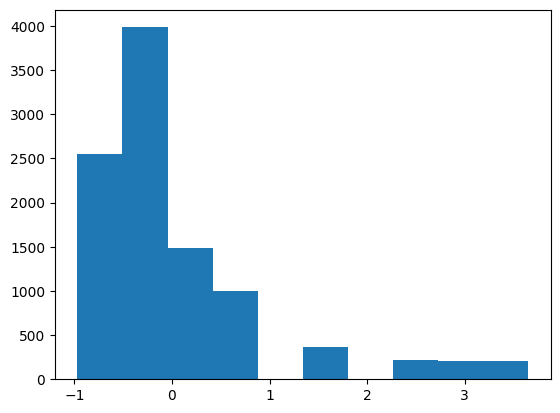

In [4]:
#Children
##Outlier assessment via histogram
medical_data['Z_Score_Children']=stats.zscore(medical_data['Children'])
medical_data[['Children', 'Z_Score_Children']].head
plt.hist(medical_data['Z_Score_Children'])

count    202.000000
mean       9.465347
std        0.500037
min        9.000000
25%        9.000000
50%        9.000000
75%       10.000000
max       10.000000
Name: Children, dtype: float64

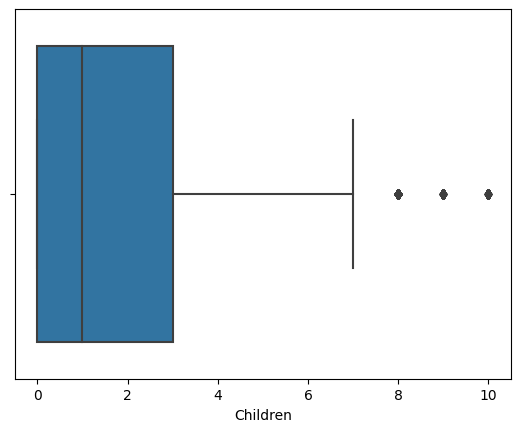

In [5]:
#Children
##Outlier assessment via box plot
children_boxplot=sns.boxplot(x='Children', data=medical_data)
children_outliers = medical_data.query('Z_Score_Children > 3 | Z_Score_Children < -3')
children_outliers['Children'].describe()

(array([1067.,  977.,  981.,  988.,  998.,  977.,  970., 1007.,  948.,
        1087.]),
 array([-1.72073600e+00, -1.37670219e+00, -1.03266837e+00, -6.88634559e-01,
        -3.44600744e-01, -5.66928963e-04,  3.43466886e-01,  6.87500701e-01,
         1.03153452e+00,  1.37556833e+00,  1.71960215e+00]),
 <BarContainer object of 10 artists>)

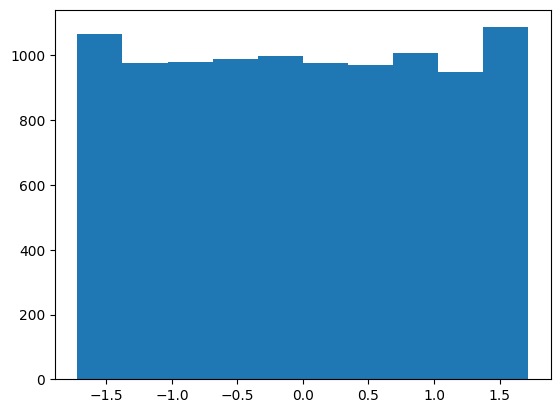

In [6]:
#Age
##Outlier assessment via histogram
medical_data['Z_Score_Age']=stats.zscore(medical_data['Age'])
medical_data[['Age', 'Z_Score_Age']].head
plt.hist(medical_data['Z_Score_Age'])

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Age, dtype: float64

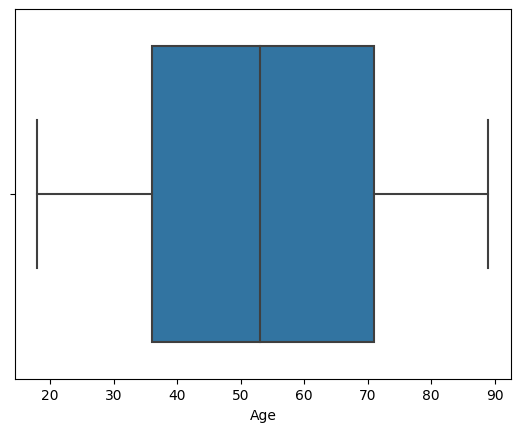

In [7]:
#Age
##Outlier assessment via box plot
age_boxplot=sns.boxplot(x='Age', data=medical_data)
age_outliers = medical_data.query('Z_Score_Age > 3 | Z_Score_Age < -3')
age_outliers['Age'].describe()

(array([2727., 3369., 2032., 1038.,  470.,  206.,   85.,   47.,   14.,
          12.]),
 array([-1.41433384, -0.68818727,  0.0379593 ,  0.76410587,  1.49025243,
         2.216399  ,  2.94254557,  3.66869213,  4.3948387 ,  5.12098527,
         5.84713184]),
 <BarContainer object of 10 artists>)

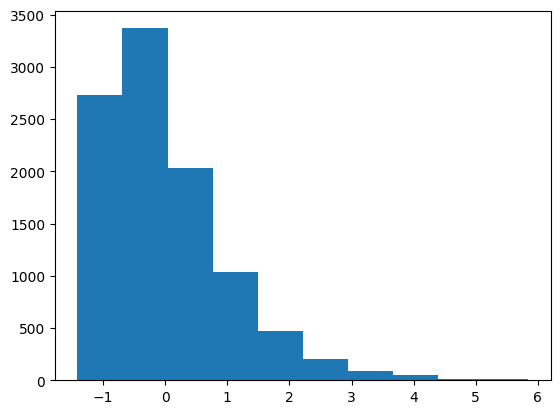

In [8]:
#Income
##Outlier assessment via histogram
medical_data['Z_Score_Income']=stats.zscore(medical_data['Income'])
medical_data[['Income', 'Z_Score_Income']].head
plt.hist(medical_data['Z_Score_Income'])

count       143.000000
mean     149508.080699
std       19581.744082
min      126063.690000
25%      133294.575000
50%      145193.000000
75%      161234.000000
max      207249.100000
Name: Income, dtype: float64

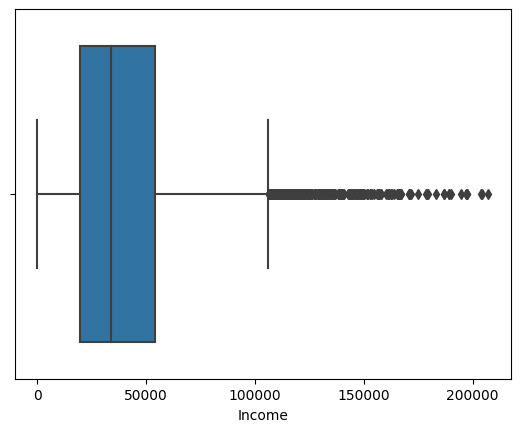

In [9]:
#Income
##Outlier assessment via box plot
income_boxplot=sns.boxplot(x='Income', data=medical_data)
income_outliers = medical_data.query('Z_Score_Income > 3 | Z_Score_Income < -3')
income_outliers['Income'].describe()

(array([   4.,   69.,  498., 1677., 3085., 2769., 1450.,  393.,   51.,
           4.]),
 array([-4.04424997, -3.22189522, -2.39954048, -1.57718573, -0.75483099,
         0.06752375,  0.8898785 ,  1.71223324,  2.53458799,  3.35694273,
         4.17929747]),
 <BarContainer object of 10 artists>)

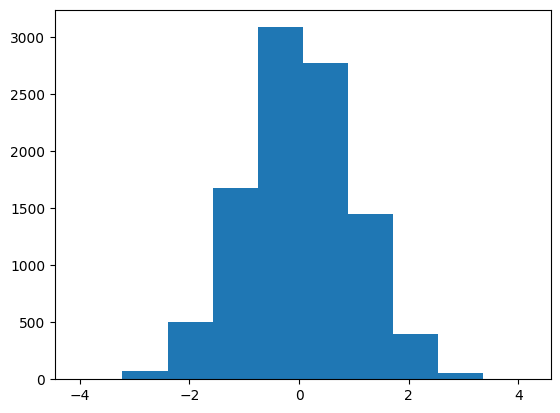

In [10]:
#VitD_levels
##Outlier assessment via histogram
medical_data['Z_Score_VitD_levels']=stats.zscore(medical_data['VitD_levels'])
medical_data[['VitD_levels', 'Z_Score_VitD_levels']].head
plt.hist(medical_data['Z_Score_VitD_levels'])

count    24.000000
mean     19.094855
std       6.824717
min       9.806483
25%      11.697978
50%      24.261485
75%      24.560715
max      26.394449
Name: VitD_levels, dtype: float64

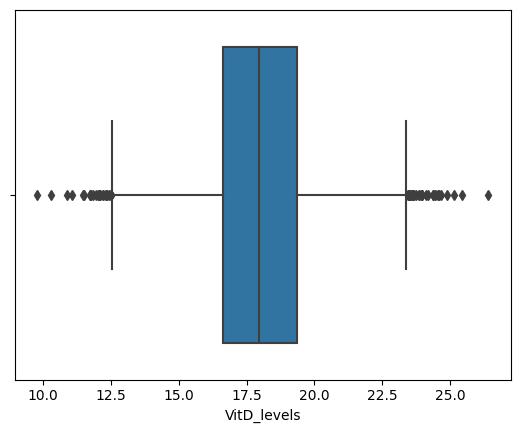

In [11]:
#VitD_levels
##Outlier assessment via box plot
vitD_levels_boxplot=sns.boxplot(x='VitD_levels', data=medical_data)
vitD_levels_outliers = medical_data.query('Z_Score_VitD_levels > 3 | Z_Score_VitD_levels < -3')
vitD_levels_outliers['VitD_levels'].describe()

(array([6.000e+00, 5.800e+01, 5.950e+02, 2.385e+03, 0.000e+00, 3.823e+03,
        2.436e+03, 6.340e+02, 6.100e+01, 2.000e+00]),
 array([-3.83692119, -3.07187036, -2.30681952, -1.54176869, -0.77671786,
        -0.01166703,  0.75338381,  1.51843464,  2.28348547,  3.04853631,
         3.81358714]),
 <BarContainer object of 10 artists>)

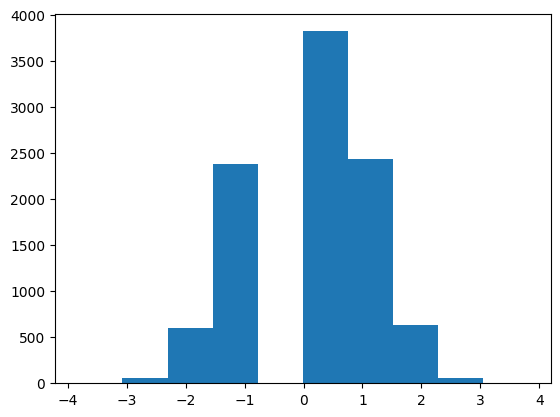

In [12]:
#Doc_visits
##Outlier assessment via histogram
medical_data['Z_Score_Doc_visits']=stats.zscore(medical_data['Doc_visits'])
medical_data[['Doc_visits', 'Z_Score_Doc_visits']].head
plt.hist(medical_data['Z_Score_Doc_visits'])

count    8.00000
mean     3.00000
std      3.70328
min      1.00000
25%      1.00000
50%      1.00000
75%      3.00000
max      9.00000
Name: Doc_visits, dtype: float64

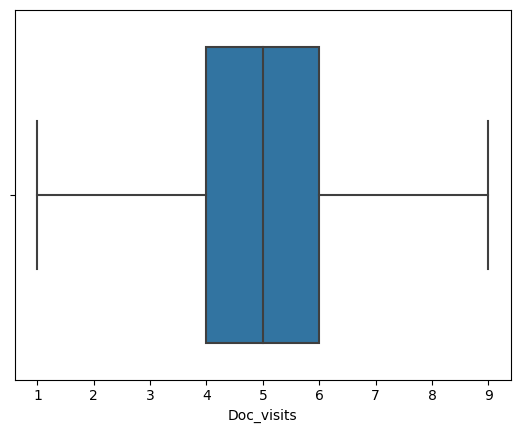

In [13]:
#Doc_visits
##Outlier assessment via box plot
doc_visits_boxplot=sns.boxplot(x='Doc_visits', data=medical_data)
doc_visits_outliers = medical_data.query('Z_Score_Doc_visits > 3 | Z_Score_Doc_visits < -3')
doc_visits_outliers['Doc_visits'].describe()

(array([3.715e+03, 3.615e+03, 1.856e+03, 0.000e+00, 6.120e+02, 1.690e+02,
        0.000e+00, 2.500e+01, 6.000e+00, 2.000e+00]),
 array([-0.99338686, -0.29898822,  0.39541043,  1.08980907,  1.78420771,
         2.47860636,  3.173005  ,  3.86740364,  4.56180229,  5.25620093,
         5.95059957]),
 <BarContainer object of 10 artists>)

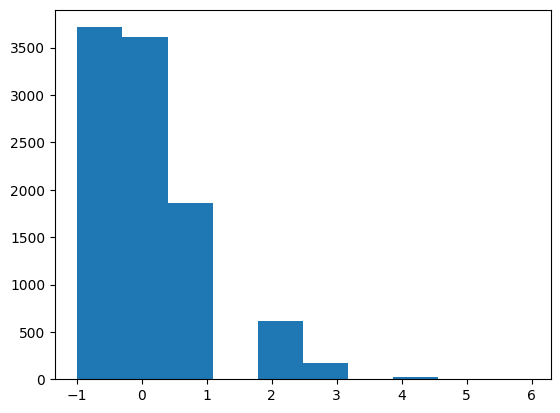

In [14]:
#Full_meals_eaten
##Outlier assessment via histogram
medical_data['Z_Score_Full_meals_eaten']=stats.zscore(medical_data['Full_meals_eaten'])
medical_data[['Full_meals_eaten', 'Z_Score_Full_meals_eaten']].head
plt.hist(medical_data['Z_Score_Full_meals_eaten'])

count    33.000000
mean      5.303030
std       0.585494
min       5.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       7.000000
Name: Full_meals_eaten, dtype: float64

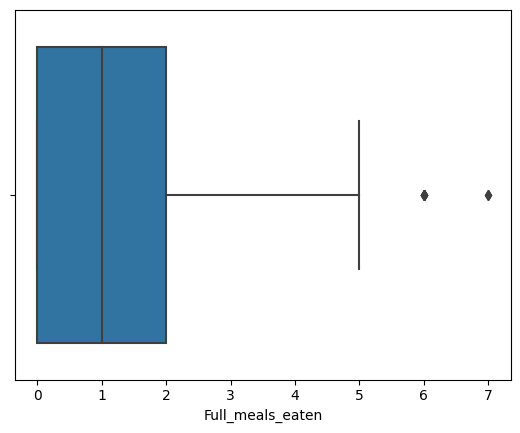

In [15]:
#Full_meals_eaten
##Outlier assessment via box plot
full_meals_eaten_boxplot=sns.boxplot(x='Full_meals_eaten', data=medical_data)
full_meals_eaten_outliers = medical_data.query('Z_Score_Full_meals_eaten > 3 | Z_Score_Full_meals_eaten < -3')
full_meals_eaten_outliers['Full_meals_eaten'].describe()

(array([6.702e+03, 2.684e+03, 0.000e+00, 5.440e+02, 0.000e+00, 0.000e+00,
        6.400e+01, 0.000e+00, 5.000e+00, 1.000e+00]),
 array([-0.63471264,  0.160866  ,  0.95644465,  1.75202329,  2.54760193,
         3.34318058,  4.13875922,  4.93433787,  5.72991651,  6.52549516,
         7.3210738 ]),
 <BarContainer object of 10 artists>)

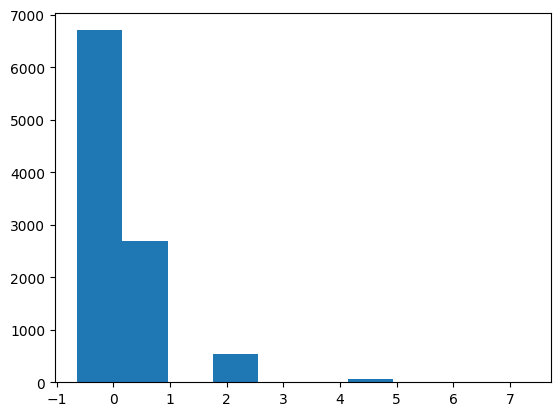

In [16]:
#VitD_supp
##Outlier assessment via histogram
medical_data['Z_Score_vitD_supp']=stats.zscore(medical_data['vitD_supp'])
medical_data[['vitD_supp', 'Z_Score_vitD_supp']].head
plt.hist(medical_data['Z_Score_vitD_supp'])

count    70.000000
mean      3.100000
std       0.346828
min       3.000000
25%       3.000000
50%       3.000000
75%       3.000000
max       5.000000
Name: vitD_supp, dtype: float64

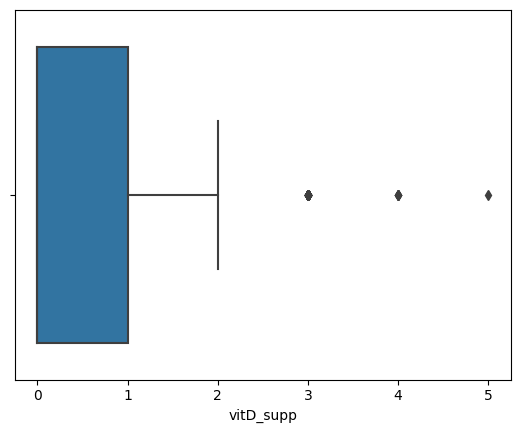

In [17]:
#VitD_supp
##Outlier assessment via box plot
vitd_supp_boxplot=sns.boxplot(x='vitD_supp', data=medical_data)
vitd_supp_outliers = medical_data.query('Z_Score_vitD_supp > 3 | Z_Score_vitD_supp < -3')
vitd_supp_outliers['vitD_supp'].describe()

(array([2563., 1586.,  669.,  157.,   34.,  271.,  546., 1033., 1451.,
        1690.]),
 array([-1.27160124, -1.00179951, -0.73199778, -0.46219605, -0.19239432,
         0.07740741,  0.34720914,  0.61701087,  0.88681261,  1.15661434,
         1.42641607]),
 <BarContainer object of 10 artists>)

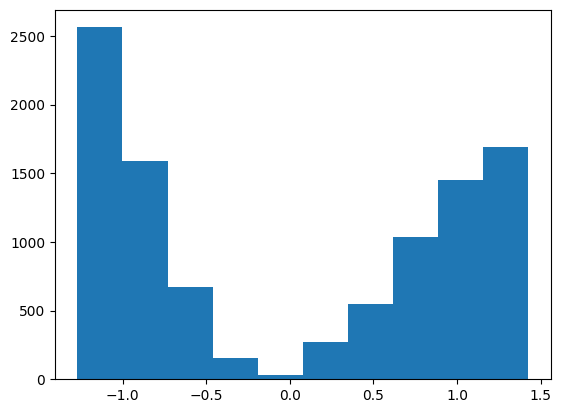

In [18]:
#Initial_days
##Outlier assessment via histogram
medical_data['Z_Score_Initial_days']=stats.zscore(medical_data['Initial_days'])
medical_data[['Initial_days', 'Z_Score_Initial_days']].head
plt.hist(medical_data['Z_Score_Initial_days'])

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Initial_days, dtype: float64

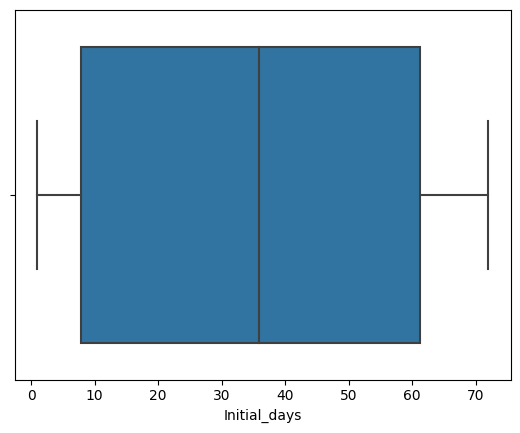

In [19]:
#Initial_days
##Outlier assessment via box plot
initial_days_boxplot=sns.boxplot(x='Initial_days', data=medical_data)
initial_days_outliers = medical_data.query('Z_Score_Initial_days > 3 | Z_Score_Initial_days < -3')
initial_days_outliers['Initial_days'].describe()

(array([ 817., 2325., 1381.,  420.,  145.,  423., 1049., 1614., 1522.,
         304.]),
 array([-1.54744035, -1.21526284, -0.88308532, -0.5509078 , -0.21873029,
         0.11344723,  0.44562474,  0.77780226,  1.10997977,  1.44215729,
         1.7743348 ]),
 <BarContainer object of 10 artists>)

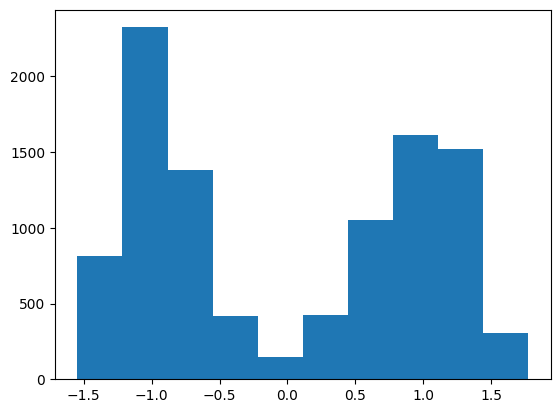

In [20]:
#TotalCharge
##Outlier assessment via histogram
medical_data['Z_Score_TotalCharge']=stats.zscore(medical_data['TotalCharge'])
medical_data[['TotalCharge', 'Z_Score_TotalCharge']].head
plt.hist(medical_data['Z_Score_TotalCharge'])

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: TotalCharge, dtype: float64

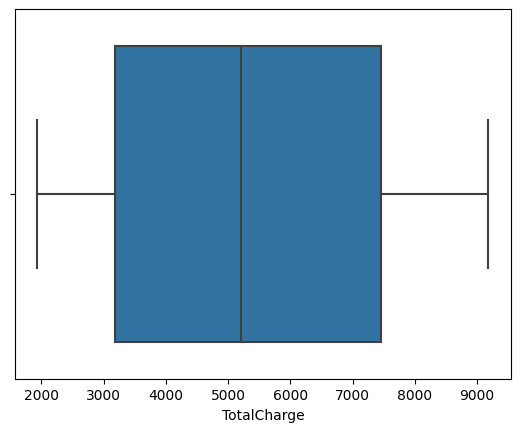

In [21]:
#TotalCharge
##Outlier assessment via box plot
totalCharge_boxplot=sns.boxplot(x='TotalCharge', data=medical_data)
totalCharge_outliers = medical_data.query('Z_Score_TotalCharge > 3 | Z_Score_TotalCharge < -3')
totalCharge_outliers['TotalCharge'].describe()

(array([1120., 1818., 1891., 1856., 1032.,  497.,  494.,  507.,  487.,
         298.]),
 array([-1.49929902, -1.07986741, -0.66043579, -0.24100418,  0.17842743,
         0.59785904,  1.01729065,  1.43672227,  1.85615388,  2.27558549,
         2.6950171 ]),
 <BarContainer object of 10 artists>)

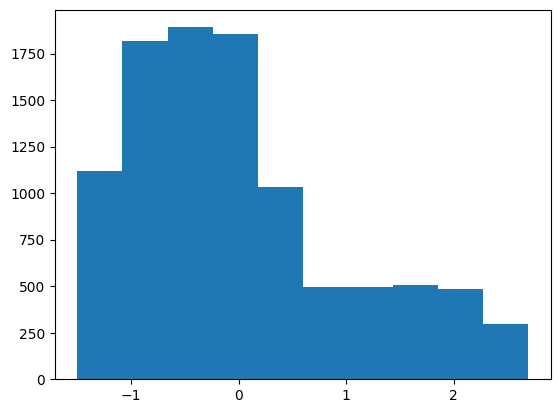

In [22]:
#Additional_charges
##Outlier assessment via histogram
medical_data['Z_Score_Additional_charges']=stats.zscore(medical_data['Additional_charges'])
medical_data[['Additional_charges', 'Z_Score_Additional_charges']].head
plt.hist(medical_data['Z_Score_Additional_charges'])

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Additional_charges, dtype: float64

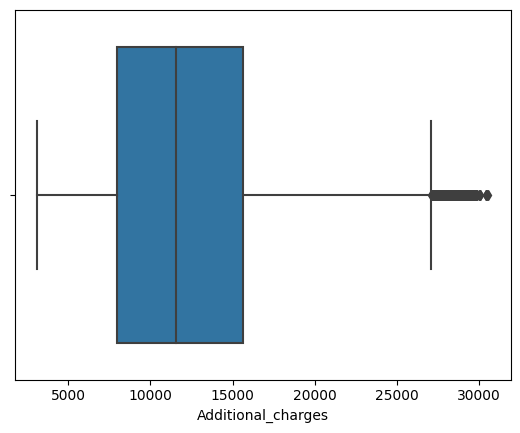

In [23]:
#Additional_charges
##Outlier assessment via box plot
additional_charges_boxplot=sns.boxplot(x='Additional_charges', data=medical_data)
additional_charges_outliers = medical_data.query('Z_Score_Additional_charges > 3 | Z_Score_Additional_charges < -3')
additional_charges_outliers['Additional_charges'].describe()

<b>Summary statistics for the retained variables:</b>

In [24]:
medical_data['Children'].describe()

count    10000.000000
mean         2.097200
std          2.163659
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         10.000000
Name: Children, dtype: float64

In [25]:
medical_data['Age'].describe()

count    10000.000000
mean        53.511700
std         20.638538
min         18.000000
25%         36.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64

In [26]:
medical_data['Income'].describe()

count     10000.000000
mean      40490.495160
std       28521.153293
min         154.080000
25%       19598.775000
50%       33768.420000
75%       54296.402500
max      207249.100000
Name: Income, dtype: float64

In [27]:
medical_data['VitD_levels'].describe()

count    10000.000000
mean        17.964262
std          2.017231
min          9.806483
25%         16.626439
50%         17.951122
75%         19.347963
max         26.394449
Name: VitD_levels, dtype: float64

In [28]:
medical_data['Doc_visits'].describe()

count    10000.000000
mean         5.012200
std          1.045734
min          1.000000
25%          4.000000
50%          5.000000
75%          6.000000
max          9.000000
Name: Doc_visits, dtype: float64

In [29]:
medical_data['Full_meals_eaten'].describe()

count    10000.000000
mean         1.001400
std          1.008117
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: Full_meals_eaten, dtype: float64

In [30]:
medical_data['vitD_supp'].describe()

count    10000.000000
mean         0.398900
std          0.628505
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: vitD_supp, dtype: float64

In [31]:
medical_data['Initial_days'].describe()

count    10000.000000
mean        34.455299
std         26.309341
min          1.001981
25%          7.896215
50%         35.836244
75%         61.161020
max         71.981490
Name: Initial_days, dtype: float64

In [32]:
medical_data['TotalCharge'].describe()

count    10000.000000
mean      5312.172769
std       2180.393838
min       1938.312067
25%       3179.374015
50%       5213.952000
75%       7459.699750
max       9180.728000
Name: TotalCharge, dtype: float64

In [33]:
medical_data['Additional_charges'].describe()

count    10000.000000
mean     12934.528587
std       6542.601544
min       3125.703000
25%       7986.487755
50%      11573.977735
75%      15626.490000
max      30566.070000
Name: Additional_charges, dtype: float64

In [34]:
medical_data['Area'].value_counts() #One-hot

Area
Rural       3369
Suburban    3328
Urban       3303
Name: count, dtype: int64

In [35]:
medical_data['Marital'].value_counts() #One-hot

Marital
Widowed          2045
Married          2023
Separated        1987
Never Married    1984
Divorced         1961
Name: count, dtype: int64

In [36]:
medical_data['Gender'].value_counts() #One-hot

Gender
Female       5018
Male         4768
Nonbinary     214
Name: count, dtype: int64

In [37]:
medical_data['ReAdmis'].value_counts()

ReAdmis
No     6331
Yes    3669
Name: count, dtype: int64

In [38]:
medical_data['Soft_drink'].value_counts()

Soft_drink
No     7425
Yes    2575
Name: count, dtype: int64

In [39]:
medical_data['Initial_admin'].value_counts() #One-hot

Initial_admin
Emergency Admission      5060
Elective Admission       2504
Observation Admission    2436
Name: count, dtype: int64

In [40]:
medical_data['HighBlood'].value_counts()

HighBlood
No     5910
Yes    4090
Name: count, dtype: int64

In [41]:
medical_data['Stroke'].value_counts()

Stroke
No     8007
Yes    1993
Name: count, dtype: int64

In [42]:
medical_data['Complication_risk'].value_counts() #One-hot

Complication_risk
Medium    4517
High      3358
Low       2125
Name: count, dtype: int64

In [43]:
medical_data['Overweight'].value_counts()

Overweight
Yes    7094
No     2906
Name: count, dtype: int64

In [44]:
medical_data['Arthritis'].value_counts()

Arthritis
No     6426
Yes    3574
Name: count, dtype: int64

In [45]:
medical_data['Diabetes'].value_counts()

Diabetes
No     7262
Yes    2738
Name: count, dtype: int64

In [46]:
medical_data['Hyperlipidemia'].value_counts()

Hyperlipidemia
No     6628
Yes    3372
Name: count, dtype: int64

In [47]:
medical_data['BackPain'].value_counts()

BackPain
No     5886
Yes    4114
Name: count, dtype: int64

In [48]:
medical_data['Anxiety'].value_counts()

Anxiety
No     6785
Yes    3215
Name: count, dtype: int64

In [49]:
medical_data['Allergic_rhinitis'].value_counts()

Allergic_rhinitis
No     6059
Yes    3941
Name: count, dtype: int64

In [50]:
medical_data['Reflux_esophagitis'].value_counts()

Reflux_esophagitis
No     5865
Yes    4135
Name: count, dtype: int64

In [51]:
medical_data['Asthma'].value_counts()

Asthma
No     7107
Yes    2893
Name: count, dtype: int64

In [52]:
medical_data['Services'].value_counts() #One-hot

Services
Blood Work     5265
Intravenous    3130
CT Scan        1225
MRI             380
Name: count, dtype: int64

<b>Conversion of categorical variables:</b>

In [53]:
#Convert categorical variables to Dummy Variables by either Ordinal or One-hot encoding

#ReAdmis
medical_data['ReAdmis'] = medical_data['ReAdmis'].replace({"Yes": 1, "No": 0})
medical_data['ReAdmis'].unique()

array([0, 1], dtype=int64)

In [54]:
#Soft_drink
medical_data['Soft_drink'] = medical_data['Soft_drink'].replace({"Yes": 1, "No": 0})
medical_data['Soft_drink'].unique()

array([0, 1], dtype=int64)

In [55]:
#HighBlood
medical_data['HighBlood'] = medical_data['HighBlood'].replace({"Yes": 1, "No": 0})
medical_data['HighBlood'].unique()

array([1, 0], dtype=int64)

In [56]:
#Stroke
medical_data['Stroke'] = medical_data['Stroke'].replace({"Yes": 1, "No": 0})
medical_data['Stroke'].unique()

array([0, 1], dtype=int64)

In [57]:
#Overweight
medical_data['Overweight'] = medical_data['Overweight'].replace({"Yes": 1, "No": 0})
medical_data['Overweight'].unique()

array([0, 1], dtype=int64)

In [58]:
#Arthritis
medical_data['Arthritis'] = medical_data['Arthritis'].replace({"Yes": 1, "No": 0})
medical_data['Arthritis'].unique()

array([1, 0], dtype=int64)

In [59]:
#Diabetes
medical_data['Diabetes'] = medical_data['Diabetes'].replace({"Yes": 1, "No": 0})
medical_data['Diabetes'].unique()

array([1, 0], dtype=int64)

In [60]:
#Hyperlipidemia
medical_data['Hyperlipidemia'] = medical_data['Hyperlipidemia'].replace({"Yes": 1, "No": 0})
medical_data['Hyperlipidemia'].unique()

array([0, 1], dtype=int64)

In [61]:
#BackPain
medical_data['BackPain'] = medical_data['BackPain'].replace({"Yes": 1, "No": 0})
medical_data['BackPain'].unique()

array([1, 0], dtype=int64)

In [62]:
#Anxiety
medical_data['Anxiety'] = medical_data['Anxiety'].replace({"Yes": 1, "No": 0})
medical_data['Anxiety'].unique()

array([1, 0], dtype=int64)

In [63]:
#Allergic_rhinitis
medical_data['Allergic_rhinitis'] = medical_data['Allergic_rhinitis'].replace({"Yes": 1, "No": 0})
medical_data['Allergic_rhinitis'].unique()

array([1, 0], dtype=int64)

In [64]:
#Reflux_esophagitis
medical_data['Reflux_esophagitis'] = medical_data['Reflux_esophagitis'].replace({"Yes": 1, "No": 0})
medical_data['Reflux_esophagitis'].unique()

array([0, 1], dtype=int64)

In [65]:
#Asthma
medical_data['Asthma'] = medical_data['Asthma'].replace({"Yes": 1, "No": 0})
medical_data['Asthma'].unique()

array([1, 0], dtype=int64)

In [66]:
##Create new dataframe that only has the variables we are keeping, will help keep things clean

kept_columns = ['Children', 'Age', 'Income', 'VitD_levels', 'Doc_visits', 'Full_meals_eaten',
                'vitD_supp', 'Initial_days', 'TotalCharge', 'Additional_charges', 'Area',
                'Marital', 'Gender', 'ReAdmis', 'Soft_drink', 'Initial_admin', 'HighBlood',
                'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia',
                'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']
medical_data2 = medical_data[kept_columns]
medical_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Children            10000 non-null  int64  
 1   Age                 10000 non-null  int64  
 2   Income              10000 non-null  float64
 3   VitD_levels         10000 non-null  float64
 4   Doc_visits          10000 non-null  int64  
 5   Full_meals_eaten    10000 non-null  int64  
 6   vitD_supp           10000 non-null  int64  
 7   Initial_days        10000 non-null  float64
 8   TotalCharge         10000 non-null  float64
 9   Additional_charges  10000 non-null  float64
 10  Area                10000 non-null  object 
 11  Marital             10000 non-null  object 
 12  Gender              10000 non-null  object 
 13  ReAdmis             10000 non-null  int64  
 14  Soft_drink          10000 non-null  int64  
 15  Initial_admin       10000 non-null  object 
 16  HighB

In [67]:
##One-hot - Area, Marital, Gender, Initial_admin, Complication_risk, Services
medical_data_encoded = pd.get_dummies(medical_data2, columns = ['Area', 
                                                               'Marital', 'Gender', 'Initial_admin',
                                                               'Complication_risk', 'Services'], drop_first=True, dtype=int)

In [68]:
##View info for new dataframe to make sure all variable types are correct
medical_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Children                             10000 non-null  int64  
 1   Age                                  10000 non-null  int64  
 2   Income                               10000 non-null  float64
 3   VitD_levels                          10000 non-null  float64
 4   Doc_visits                           10000 non-null  int64  
 5   Full_meals_eaten                     10000 non-null  int64  
 6   vitD_supp                            10000 non-null  int64  
 7   Initial_days                         10000 non-null  float64
 8   TotalCharge                          10000 non-null  float64
 9   Additional_charges                   10000 non-null  float64
 10  ReAdmis                              10000 non-null  int64  
 11  Soft_drink                   

<b>Split dataframe into X and y:</b>

In [69]:
##Split dataframe into X and y (ReAdmis is y)
medical_data_X = medical_data_encoded.drop('ReAdmis', axis=1)
medical_data_y = medical_data_encoded['ReAdmis']

<b>Scale features for X:</b>

In [70]:
min_max_scaler = MinMaxScaler()
medical_data_X = pd.DataFrame(min_max_scaler.fit_transform(medical_data_X), columns=medical_data_X.columns)
medical_data_X.head()

,Children,Age,Income,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Initial_days,TotalCharge,Additional_charges,...,Marital_Widowed,Gender_Male,Gender_Nonbinary,Initial_admin_Emergency Admission,Initial_admin_Observation Admission,Complication_risk_Low,Complication_risk_Medium,Services_CT Scan,Services_Intravenous,Services_MRI
0,0.1,0.492958,0.417305,0.562756,0.625,0.000000,0.0,0.135022,0.246933,0.539851,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.3,0.464789,0.225268,0.550632,0.375,0.285714,0.2,0.199037,0.311343,0.527956,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.3,0.492958,0.068645,0.497410,0.375,0.142857,0.0,0.053117,0.068475,0.524027,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.845070,0.191156,0.408150,0.375,0.142857,0.0,0.010044,0.026168,0.359607,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.1,0.056338,0.005097,0.460128,0.500,0.000000,0.4,0.003562,0.024130,0.021531,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [71]:
medical_data_y.head()

0    0
1    0
2    0
3    0
4    0
Name: ReAdmis, dtype: int64

<b>SelectKBest:</b>

In [72]:
#Initialize the class and call fit_transform
skbest = SelectKBest(f_classif, k='all')
skbest.fit_transform(medical_data_X, medical_data_y)


#Finding p-values to select statistically significant features
p_values= pd.DataFrame({'Feature': medical_data_X.columns, 'p_value': skbest.pvalues_}).sort_values('p_value')
p_values[p_values['p_value'] < 0.05]

,Feature,p_value
7,Initial_days,0.000000
8,TotalCharge,0.000000
34,Services_CT Scan,0.014707
0,Children,0.018613
35,Services_Intravenous,0.042233
30,Initial_admin_Emergency Admission,0.048766


<b>Correlation matrix and VIF:</b>

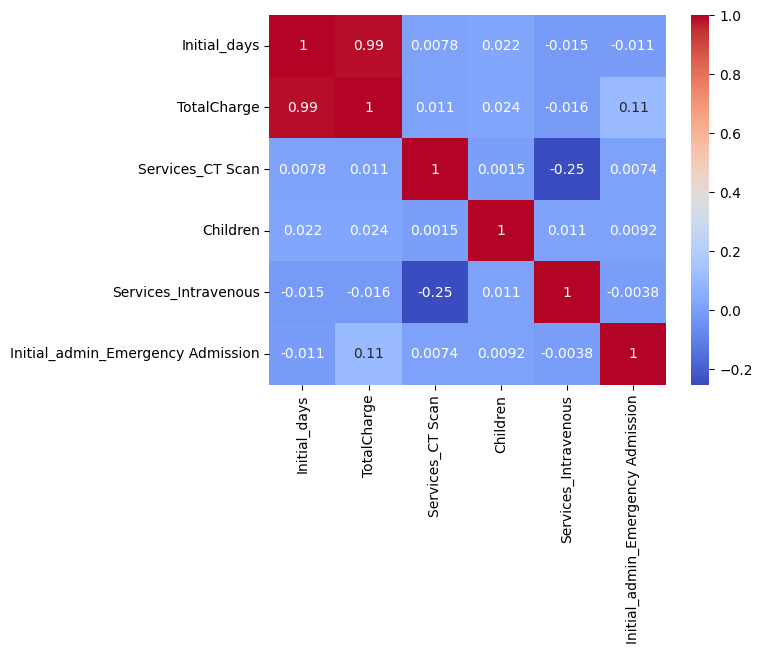

In [73]:
##Correlation matrix and VIF
#Correlation matrix - Attempt 1
corr_data = medical_data_encoded[['Initial_days', 'TotalCharge', 'Services_CT Scan', 'Children', 
                                  'Services_Intravenous', 'Initial_admin_Emergency Admission']]
corr_matrix = corr_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [74]:
#VIF - Attempt 1
vif_data = pd.DataFrame()
vif_data["feature"] = corr_data.columns

vif_data["VIF"] = [variance_inflation_factor(corr_data.values, i)
for i in range(len(corr_data.columns))]
print(vif_data)

                             feature        VIF
0                       Initial_days  22.287475
1                        TotalCharge  34.171565
2                   Services_CT Scan   1.216006
3                           Children   1.927813
4               Services_Intravenous   1.545364
5  Initial_admin_Emergency Admission   2.596285


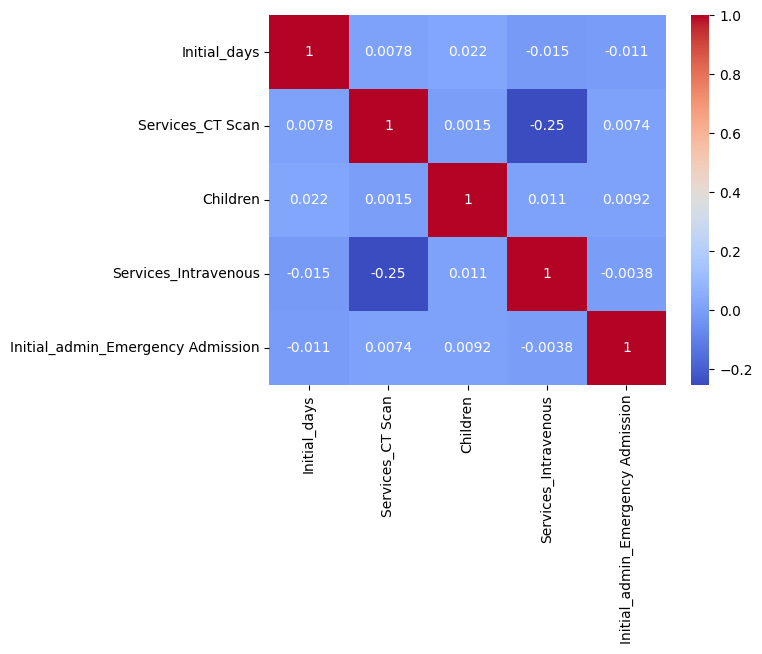

In [75]:
#Correlation matrix - Attempt 2
corr_data = medical_data_encoded[['Initial_days', 'Services_CT Scan', 'Children', 
                                  'Services_Intravenous', 'Initial_admin_Emergency Admission']]
corr_matrix = corr_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [76]:
#VIF - Attempt 2
vif_data = pd.DataFrame()
vif_data["feature"] = corr_data.columns

vif_data["VIF"] = [variance_inflation_factor(corr_data.values, i)
for i in range(len(corr_data.columns))]
print(vif_data)

                             feature       VIF
0                       Initial_days  1.857540
1                   Services_CT Scan  1.150041
2                           Children  1.636978
3               Services_Intravenous  1.368962
4  Initial_admin_Emergency Admission  1.637408


#### 4. Provide a copy of the cleaned data set.

In [77]:
#Question C4
##Make copy of dataset and output it
cleaned_data = pd.concat([medical_data_X, medical_data_y], axis = 1)
cleaned_data.to_csv('cleaned_medical_data.csv', index = False)

## Part IV: Analysis

### D. Perform the data analysis and report on the results by doing the following:

#### 1. Split the data into training and test data sets and provide the file(s).

In [78]:
X = medical_data_X[['Initial_days', 'Services_CT Scan', 'Children', 
                                  'Services_Intravenous', 'Initial_admin_Emergency Admission']]
y = medical_data_y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1111, stratify = y)

In [79]:
X_train.to_csv('X_train.csv', index = False)

In [80]:
X_test.to_csv('X_test.csv', index = False)

In [81]:
y_train.to_csv('y_train.csv', index = False)

In [82]:
y_test.to_csv('y_test.csv', index = False)

#### 2. Describe the analysis technique you used to appropriately analyze the data. Include screenshots of the intermediate calculations you performed.

The analysis technique used to appropriately analyze the data is a k-nearest neighbors classification algorithm. As noted in Section B1, this algorithm is appropriate as it seeks to use information obtained from labeled points to classify unlabeled points. This technique relies on specifying the number of neighbors used, which in this instance will be done using hyperparameter tuning.

Correctly picking the right value for k (number of neighbors) is vital to the correct functioning of the algorithm. According to datasklr.com, "When K=1, the decision boundary is minimally restricted,  KNN models are said to produce low bias but high variance.  As we increase K, the flexibility of the classifier gets reduced and the decision boundary gets closer and closer to linear. These models produce low variance but high bias." If the value of k is too low or too high, the model could suffer from variance or bias issues, respectively.

GridSearchCV was used to help identify the ideal number of neighbors. This cross-validation method looks at the performance for a variety of potential numbers for 'k' and chooses the 'k' with the best value. For this specific task, the number was 8. 

Finally, the algorithm is assessed for performance via a variety of methods, including a ROC curve, AUC score, a confusion matrix, and accuracy score.

In [83]:
##Set up parameters
parameters = {'n_neighbors':np.arange(1,50)}

##instantiate KNN
knn = KNeighborsClassifier()

##instantiate GridSearchCV
knncv = GridSearchCV(knn, parameters, cv = 5)

##fit KNN to training data
knncv.fit(X_train, y_train)

##Find best parameter value
knncv.best_params_

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

...

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

{'n_neighbors': 8}

In [84]:
knncv.best_score_

0.979875

In [85]:
##Use best parameter for k
knn = KNeighborsClassifier(n_neighbors = 8)
knn.fit(X_train, y_train)
print("The score (accuracy) of the KNN model:")
print(knn.score(X_test, y_test))

The score (accuracy) of the KNN model:
0.97


C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [86]:
y_pred = knn.predict(X_test)
print("The confusion matrix for the KNN model:")
print(confusion_matrix(y_test, y_pred))

The confusion matrix for the KNN model:
[[1237   29]
 [  31  703]]


C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [87]:
y_pred_proba = knn.predict_proba(X_test)[:,1]
print("The Area Under the Curve (AUC) for the KNN model:")
print(roc_auc_score(y_test, y_pred_proba))

The Area Under the Curve (AUC) for the KNN model:
0.9939827429609447


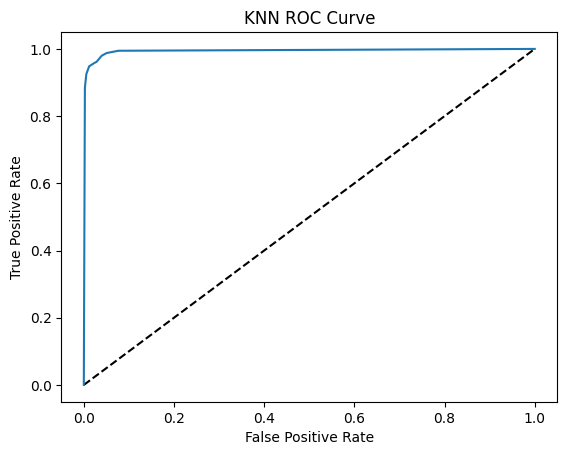

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1266
           1       0.96      0.96      0.96       734

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [88]:
##Generate confusion matrix, AUC/ROC, training/testing accuracy - plot code taken from "Machine Learning with scikit-learn" DataCamp
y_pred_prob = knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr, label = 'K-Nearest Neighbors')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.show()

print(classification_report(y_test, y_pred))

#### 3. Provide the code used to perform the classification analysis from part D2.

In [89]:
#The below is the same code from D1 and D2. It is restated in order to fulfill the requirement for Section D3.

##train_test_split, export 4 datasets (X_train, y_train, X_test, y_test)
X = medical_data_X[['Initial_days', 'Services_CT Scan', 'Children', 
                                  'Services_Intravenous', 'Initial_admin_Emergency Admission']]
y = medical_data_y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1111, stratify = y)
X_train.to_csv('X_train.csv', index = False)
X_test.to_csv('X_test.csv', index = False)
y_train.to_csv('y_train.csv', index = False)
y_test.to_csv('y_test.csv', index = False)

##Set up parameters
parameters = {'n_neighbors':np.arange(1,50)}

##instantiate KNN
knn = KNeighborsClassifier()

##instantiate GridSearchCV
knncv = GridSearchCV(knn, parameters, cv = 5)

##fit KNN to training data
knncv.fit(X_train, y_train)

##Find best parameter value
knncv.best_params_

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

...

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

{'n_neighbors': 8}

In [90]:
knncv.best_score_

0.979875

In [91]:
##Use best parameter for k
knn = KNeighborsClassifier(n_neighbors = 8)
knn.fit(X_train, y_train)
print("The score (accuracy) of the KNN model:")
print(knn.score(X_test, y_test))

The score (accuracy) of the KNN model:
0.97


C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [92]:
y_pred = knn.predict(X_test)
print("The confusion matrix for the KNN model:")
print(confusion_matrix(y_test, y_pred))

The confusion matrix for the KNN model:
[[1237   29]
 [  31  703]]


C:\Users\matth\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [93]:
y_pred_proba = knn.predict_proba(X_test)[:,1]
print("The Area Under the Curve (AUC) for the KNN model:")
print(roc_auc_score(y_test, y_pred_proba))

The Area Under the Curve (AUC) for the KNN model:
0.9939827429609447


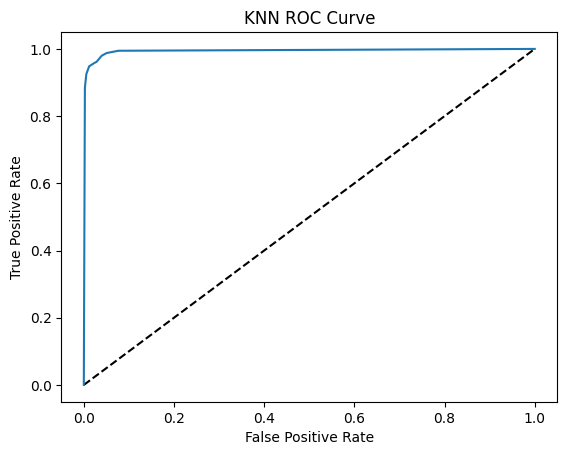

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1266
           1       0.96      0.96      0.96       734

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [94]:
##Generate confusion matrix, AUC/ROC, training/testing accuracy - plot code taken from "Machine Learning with scikit-learn" DataCamp
y_pred_prob = knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr, label = 'K-Nearest Neighbors')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.show()

print(classification_report(y_test, y_pred))

## Part V: Data Summary and Implications

### E. Summarize your data analysis by doing the following:

#### 1. Explain the accuracy and the area under the curve (AUC) of your classification model.

The accuracy of the KNN classification model is 0.97. This can be calculated via the confusion matrix by recalling that accuracy score is measured by (TN+TP)/(TN+TP+FN+FP). In this instance, that is (1237+703)/(1237+703+31+29). This gives 1940/2000, or 0.97. This score means that, on average, this classification model correctly classifies 97% of the data points in the dataset.

The area under the curve (AUC) for the KNN classification model is roughly 0.994. AUC ranges from 0 to 1, with 0.0 representing a model that has predictions that are 100% incorrect, 1.0 representing a model that has predictions that are 100% correct, and 0.5 representing a model that predicts as well as at random. The score for this model (0.994) is very high, and indicates that the model does very well at differentiating between the two classes of the binary target variable (Yes for readmission, No for readmission).

#### 2. Discuss the results and implications of your classification analysis.

The results of the KNN classification analysis are very promising. The model scores well in terms of accuracy, precision, recall, and AUC score. This is represented visually as well, with the ROC curve showing that the model is capable of a high number of true positives and a small number of false positives. 

By using hyperparameter tuning via GridSearchCV, the optimal value of k was achieved, which helps prevent overfitting/underfitting if the value of 'k' was too small or large, respectively. Additionally, using SelectKBest for feature selection played a role in aiding model performance. By selecting only the most relevant variables, this caused dimensionality reduction as well as improved model performance. By reducing dimensionality, the model became more simple and was better protected from overfitting. Additionally, model performance was improved in that it became easier for the model to generalize the training data to data the model had not yet seen, which assisted in overall model performance.

In terms of implications, the high accuracy score and AUC score can seem promising on the surface. However, high values for these scores could seem "too good to be true" and would likely benefit from further hyperparameter tuning or seeing how the model performs when applied to a dataset with entirely new patients. If the model did similarly well when handling 10,000 new instances it had not seen before, then the scores would be more trustworthy.

#### 3. Discuss one limitation of your data analysis.

One limitation of the data analysis is that several of the selected variables are relatively unbalanced in terms of groups. For example, in Section C3 we can see that 'ReAdmis' has roughly 34% of patients be readmitted within one month, and 66% that were not readmitted. For ideal model performance, this variable would be equally distributed, with roughly 50% being readmitted and 50% not being readmitted. The data imbalance toward non-readmission could lead to the KNN classification model being overly biased toward patients being not readmitted. If the readmission percentage in reality differs significantly from the percentage from our 10,000 sample dataset, this could cause applicability issues for the model. Ideally, a sample dataset with more equal distribution could be used to see if the current model suffers from bias issues.

#### 4. Recommend a course of action for the real-world organizational situation from part A1 based on your results and implications discussed in part E2.

Based on the classification model's results and implications, the organization would likely benefit from using this KNN classification model to predict whether a patient will be readmitted within one month. Looking at the variables that comprise the feature set, it appears that length of initial visit, receiving a CT scan, number of children, receiving intravenous service, and being admitted via emergency admission all play the largest roles in terms of determining readmission. On the surface, all of these features make intrinsic sense, as they indicate a severe initial issue (long initial visit, variety of tests, being admitted via the ER), and we would likely expect a more severe initial admission reason to require readmission than a less severe issue. In short, something like a malignant tumor identified via CT scan would be more likely to end up in readmission than, say, a sprained ankle.

Although the model is likely to be of great use to the organization as-is, it may still benefit the organization to test the model on entirely new unseen data to assess model applicability. In order to mitigate potential issues from past datasets, the new data would ideally be as balanced as possible.

Overall, the recommended course of action is to use the current model to predict whether a patient will be readmitted within one month, and to prioritize follow-up calls after one or two weeks with the patients deemed most likely at risk in order to potentially get out in front of whatever issue caused readmission.

## References

D209 Data Mining 1 Task 1 Cohort. WGU. (n.d.). https://westerngovernorsuniversity.sharepoint.com/:p:/r/sites/DataScienceTeam/_layouts/15/Doc.aspx?sourcedoc=%7B945F58A7-B99E-4D7A-BEC0-9BB216B4D2BD%7D&file=D209%20Data%20Mining%201%20Task%201%20Cohort.pptx&action=edit&mobileredirect=true 

Machine Learning with scikit-learn. DataCamp. (n.d.). 
https://app.datacamp.com/learn/courses/machine-learning-with-scikit-learn 

Nelson, D. (2020, August 23). What is a KNN (K-nearest neighbors)?. Unite.AI. 
https://www.unite.ai/what-is-k-nearest-neighbors/ 

Toth, G. (2020, December 22). How to tune the k-nearest neighbors classifier with Scikit-learn in Python. DataSklr. https://www.datasklr.com/select-classification-methods/k-nearest-neighbors 

What is the K-nearest neighbors algorithm?. IBM. (n.d.). 
https://www.ibm.com/topics/knn 